In [1]:
# Cell 1: Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier

# Set seed for reproducibility
np.random.seed(42)
print("Environment successfully set up!")

ModuleNotFoundError: No module named 'pandas'

In [26]:
# Cell 2: Generate sample customer dataset
n_samples = 1000

data = pd.DataFrame({
    'CustomerID': [f'CUST-{i:04d}' for i in range(1, n_samples + 1)],
    'Tenure_Months': np.random.randint(1, 72, size=n_samples),
    'MonthlyCharges': np.round(np.random.uniform(20.0, 120.0, size=n_samples), 2),
    'ContractType': np.random.choice(['Month-to-month', 'One year', 'Two year'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], size=n_samples, p=[0.4, 0.4, 0.2]),
    'PaperlessBilling': np.random.choice(['Yes', 'No'], size=n_samples, p=[0.6, 0.4]),
    'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], size=n_samples),
})

# Calculate TotalCharges (Tenure * MonthlyCharges with minor noise)
data['TotalCharges'] = np.round(data['Tenure_Months'] * data['MonthlyCharges'] + np.random.normal(0, 10, size=n_samples), 2)

# Define logic for Churn: short tenure + month-to-month + high monthly charges = higher risk
churn_prob = (
    (72 - data['Tenure_Months']) / 72 * 0.4 +
    (data['ContractType'] == 'Month-to-month') * 0.3 +
    (data['MonthlyCharges'] / 120.0) * 0.3
)
churn_prob = (churn_prob - churn_prob.min()) / (churn_prob.max() - churn_prob.min())
data['Churn'] = np.where(churn_prob > 0.55, 1, 0)

# Display first few rows
data.head()

,CustomerID,Tenure_Months,MonthlyCharges,ContractType,InternetService,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,CUST-0001,52,105.57,Month-to-month,Fiber optic,Yes,Mailed check,5500.21,1
1,CUST-0002,15,103.02,Two year,Fiber optic,No,Electronic check,1547.29,1
2,CUST-0003,61,59.72,Month-to-month,Fiber optic,Yes,Electronic check,3659.24,0
3,CUST-0004,21,86.81,One year,DSL,No,Credit card,1829.23,0
4,CUST-0005,24,40.50,One year,No,No,Bank transfer,964.43,0


Dataset Shape: (1000, 9)

Class Distribution (0 = Retained, 1 = Churned):
Churn
0    0.586
1    0.414
Name: proportion, dtype: float64


/tmp/ipykernel_3528/2033961134.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure_Months', data=data, palette='Set2')


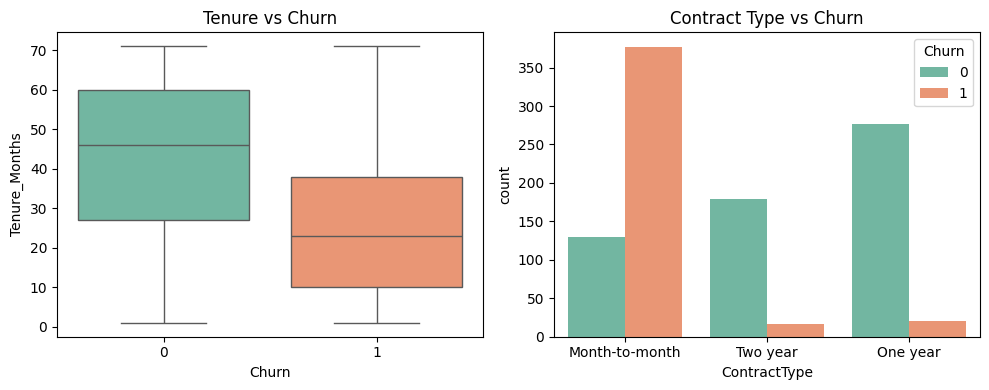

In [27]:
# Cell 3: Data Inspection & EDA
print(f"Dataset Shape: {data.shape}")
print("\nClass Distribution (0 = Retained, 1 = Churned):")
print(data['Churn'].value_counts(normalize=True))

# Visualize Tenure vs Churn
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='Tenure_Months', data=data, palette='Set2')
plt.title('Tenure vs Churn')

# Visualize Contract Type vs Churn
plt.subplot(1, 2, 2)
sns.countplot(x='ContractType', hue='Churn', data=data, palette='Set2')
plt.title('Contract Type vs Churn')
plt.tight_layout()
plt.show()

In [28]:
# Cell 4: Train/Test Split & Preprocessing Pipeline

# 1. Separate features and target
X = data.drop(columns=['CustomerID', 'Churn'])
y = data['Churn']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Identify numerical and categorical features
num_features = ['Tenure_Months', 'MonthlyCharges', 'TotalCharges']
cat_features = ['ContractType', 'InternetService', 'PaperlessBilling', 'PaymentMethod']

# 4. Construct Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 7)
Test shape: (200, 7)


In [29]:
# Cell 5: Model Training
# 1. Feature Engineering
data['MonthlyToTotalRatio'] = data['MonthlyCharges'] / (data['TotalCharges'] + 1)
data['IsNewCustomer'] = (data['Tenure_Months'] <= 6).astype(int)

# 2. Exclude 'ContractType' to remove contract bias
X_unbiased = data.drop(columns=['CustomerID', 'Churn', 'ContractType'])
y = data['Churn']

# Updated Categorical List (Without ContractType)
cat_features_unbiased = ['InternetService', 'PaperlessBilling', 'PaymentMethod']
num_features_updated = ['Tenure_Months', 'MonthlyCharges', 'TotalCharges', 'MonthlyToTotalRatio', 'IsNewCustomer']

# 3. New Preprocessor
preprocessor_unbiased = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_updated),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_unbiased)
    ]
)

# 4. Train-Test Split & Re-fit Pipeline
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unbiased, y, test_size=0.20, random_state=42, stratify=y
)

model_unbiased = Pipeline(steps=[
    ('preprocessor', preprocessor_unbiased),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

model_unbiased.fit(X_train_u, y_train_u)
print("Unbiased Model Trained Successfully!")

Unbiased Model Trained Successfully!


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.68      0.83      0.75       117
           1       0.65      0.45      0.53        83

    accuracy                           0.67       200
   macro avg       0.66      0.64      0.64       200
weighted avg       0.67      0.67      0.66       200

ROC-AUC Score: 0.7524


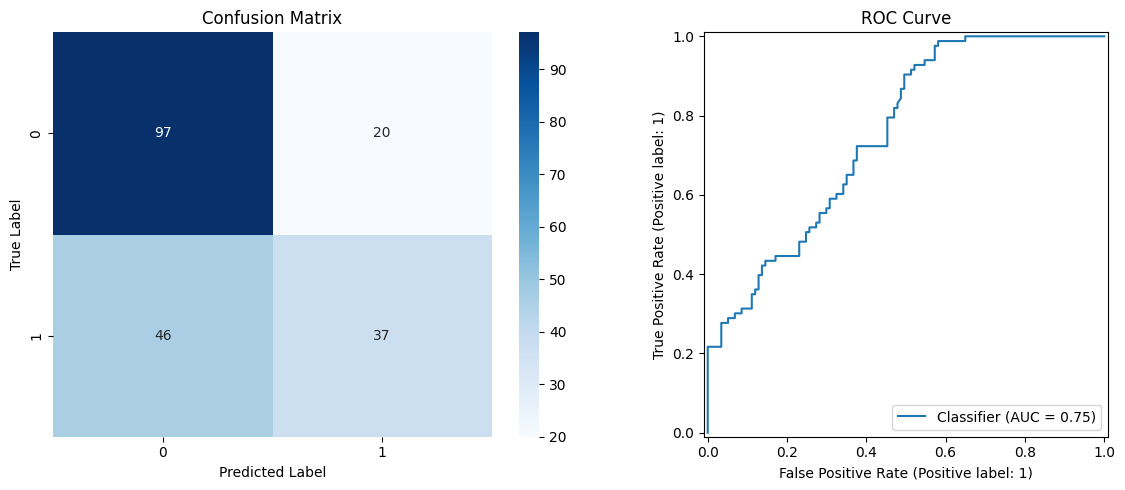

In [30]:
y_pred = model_unbiased.predict(X_test_u)
y_pred_proba = model_unbiased.predict_proba(X_test_u)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test_u, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test_u, y_pred_proba):.4f}")

# Plot Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_u, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
RocCurveDisplay.from_predictions(y_test_u, y_pred_proba, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3528/374572795.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


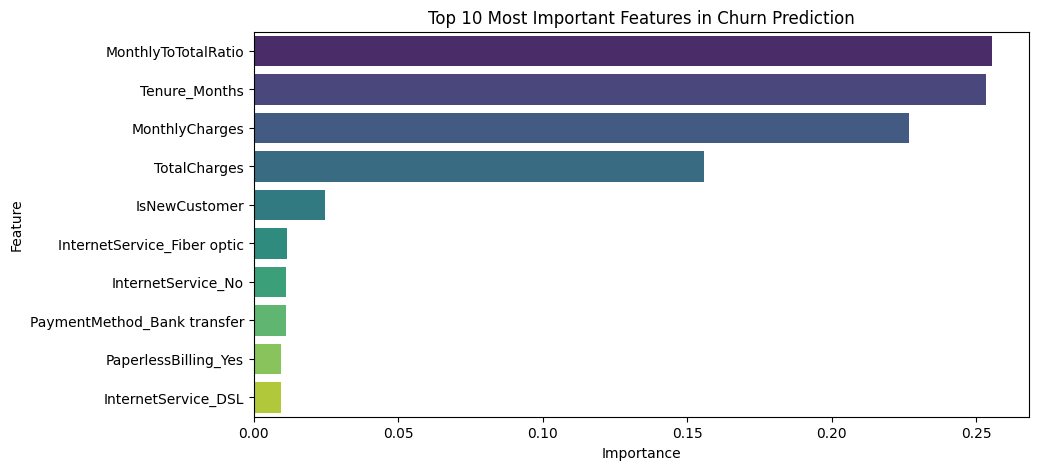

In [31]:
# Cell 7: Feature Importance Extraction
rf_model = model_unbiased.named_steps['classifier']
ohe_feature_names = model_unbiased.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(cat_features_unbiased)

all_feature_names = num_features_updated + list(ohe_feature_names)
importances = rf_model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top features
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features in Churn Prediction')
plt.show()

In [32]:
# Cell 8: Single-Customer Inference Test
new_customer_data = {
    'Tenure_Months': 24,
    'MonthlyCharges': 85.50,
    'TotalCharges': 256.50,
    'ContractType': 'month-to-month',
    'InternetService': 'Fiber optic',
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Electronic check'
}

# Create DataFrame from new customer data
new_customer_df = pd.DataFrame([new_customer_data])

# Apply the same feature engineering steps as in Cell 5
new_customer_df['MonthlyToTotalRatio'] = new_customer_df['MonthlyCharges'] / (new_customer_df['TotalCharges'] + 1)
new_customer_df['IsNewCustomer'] = (new_customer_df['Tenure_Months'] <= 6).astype(int)

# Drop 'ContractType' as it was excluded during model training
new_customer_for_prediction = new_customer_df.drop(columns=['ContractType'])

churn_probability = model_unbiased.predict_proba(new_customer_for_prediction)[0][1]
prediction = "CHURN RISK" if churn_probability > 0.5 else "SAFE"

print(f"Customer Churn Probability: {churn_probability * 100:.2f}%")
print(f"Status: {prediction}")

Customer Churn Probability: 62.73%
Status: CHURN RISK
